# Análise Estatística da Geração de Energia Solar

## 1. Introdução


Este notebook apresenta uma análise estatística dos dados de geração de energia solar e das condições meteorológicas registradas em duas usinas durante o período de 15 de maio de 2020 a 17 de junho de 2020.

Os dados originais foram previamente inspecionados, avaliados e preparados na etapa anterior do projeto, no notebook de inspeção inicial dos dados. Durante esse processo, foram analisadas a estrutura dos arquivos, a qualidade dos valores, a frequência temporal das medições, a existência de lacunas e as diferenças observadas entre as duas usinas.

Para realizar a análise estatística, serão utilizados os conjuntos processados de geração, clima e identificação das usinas. O objetivo é aplicar os conceitos estatísticos estudados e responder a perguntas relacionadas ao comportamento temporal da geração, ao desempenho das usinas e dos inversores e à relação entre geração e condições meteorológicas.

## 2. Objetivos da análise

### 2.1 Objetivo geral

Aplicar os conceitos estatísticos estudados durante as aulas para compreender o comportamento da geração de energia solar nas duas usinas e sua relação com as condições meteorológicas.

### 2.2 Perguntas da análise



1. Qual horário do dia apresenta a maior geração média de energia em cada usina?

2. Qual usina apresentou a maior geração total estimada a partir dos registros diários durante o período analisado?

3. Quais inversores apresentaram a maior geração acumulada a partir dos registros diários?

4. Em qual dia cada usina apresentou sua maior geração de energia?

5. Quais foram as condições climáticas médias registradas em cada usina?

6. Como a geração diária de cada usina se relacionou com a temperatura e a irradiação médias?

## 3. Preparação do ambiente

### 3.1 Importação das bibliotecas

In [51]:
import pandas as pd

### 3.2 Importação das funções estatísticas

In [52]:
import sys
from pathlib import Path

project_root = Path.cwd().parent

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from src.statistic import calculate_descriptive_measures, calculate_mean_median_distance, visualize_distribution

### 3.3 Configurações do notebook

## 4. Carregamento dos dados processados

In [53]:
# Carregamento dos dados
generation_df = pd.read_csv("../datasets/processados/generation_data.csv")
weather_df = pd.read_csv("../datasets/processados/weather_data.csv")
plants_df = pd.read_csv("../datasets/processados/plants.csv")

In [54]:
# Conversão das datas para datetime

generation_df["date_time"] = pd.to_datetime(
    generation_df["date_time"],
    format="%Y-%m-%d %H:%M:%S"
)

weather_df["date_time"] = pd.to_datetime(
    weather_df["date_time"],
    format="%Y-%m-%d %H:%M:%S"
)

In [55]:
generation_df.head()

,id,date_time,plant_id,plant_code,source_key,inverter_code,dc_power,ac_power,daily_yield,total_yield
0,000001-INV-P01-01,2020-05-15,4135001,P01,1BY6WEcLGh8j5v7,INV-P01-01,0.0,0.0,0.0,6259559.0
1,000002-INV-P01-02,2020-05-15,4135001,P01,1IF53ai7Xc0U56Y,INV-P01-02,0.0,0.0,0.0,6183645.0
2,000003-INV-P01-03,2020-05-15,4135001,P01,3PZuoBAID5Wc2HD,INV-P01-03,0.0,0.0,0.0,6987759.0
3,000004-INV-P01-04,2020-05-15,4135001,P01,7JYdWkrLSPkdwr4,INV-P01-04,0.0,0.0,0.0,7602960.0
4,000005-INV-P01-05,2020-05-15,4135001,P01,McdE0feGgRqW7Ca,INV-P01-05,0.0,0.0,0.0,7158964.0


In [56]:
weather_df.head()

,id,date_time,plant_id,plant_code,source_key,sensor_code,ambient_temperature,module_temperature,irradiation
0,000001-SEN-P01-01,2020-05-15 00:00:00,4135001,P01,HmiyD2TTLFNqkNe,SEN-P01-01,25.184316,22.857507,0.0
1,000002-SEN-P01-01,2020-05-15 00:15:00,4135001,P01,HmiyD2TTLFNqkNe,SEN-P01-01,25.084589,22.761668,0.0
2,000003-SEN-P01-01,2020-05-15 00:30:00,4135001,P01,HmiyD2TTLFNqkNe,SEN-P01-01,24.935753,22.592306,0.0
3,000004-SEN-P01-01,2020-05-15 00:45:00,4135001,P01,HmiyD2TTLFNqkNe,SEN-P01-01,24.846130,22.360852,0.0
4,000005-SEN-P01-01,2020-05-15 01:00:00,4135001,P01,HmiyD2TTLFNqkNe,SEN-P01-01,24.621525,22.165423,0.0


In [57]:
plants_df.head()

,plant_code,plant_id
0,P01,4135001
1,P02,4136001


### 4.1 Verificação rápida dos dados carregados

In [58]:
# Dimensões dos dataframes
print(f"Dados de geração: {generation_df.shape}")
print(f"Dados meteorológicos: {weather_df.shape}")
print(f"Dados de referência: {plants_df.shape}")

Dados de geração: (136476, 10)
Dados meteorológicos: (6441, 9)
Dados de referência: (2, 2)


In [59]:
# Verificação do tipo das colunas de data e hora
print(generation_df["date_time"].dtype)
print(weather_df["date_time"].dtype)

datetime64[us]
datetime64[us]


## 5. Preparação das bases analíticas

### 5.1 Criação das variáveis temporais

In [60]:
generation_analysis_df = generation_df.copy()
weather_analysis_df = weather_df.copy()

In [61]:
generation_analysis_df["date"] = (
    generation_analysis_df["date_time"].dt.date
)

generation_analysis_df["hour"] = (
    generation_analysis_df["date_time"].dt.hour
)

weather_analysis_df["date"] = (
    weather_analysis_df["date_time"].dt.date
)

weather_analysis_df["hour"] = (
    weather_analysis_df["date_time"].dt.hour
)

In [62]:
generation_analysis_df[
    ["date_time", "date", "hour"]
].head()

,date_time,date,hour
0,2020-05-15,2020-05-15,0
1,2020-05-15,2020-05-15,0
2,2020-05-15,2020-05-15,0
3,2020-05-15,2020-05-15,0
4,2020-05-15,2020-05-15,0


In [63]:
weather_analysis_df[
["date_time", "date", "hour"]
].head()

,date_time,date,hour
0,2020-05-15 00:00:00,2020-05-15,0
1,2020-05-15 00:15:00,2020-05-15,0
2,2020-05-15 00:30:00,2020-05-15,0
3,2020-05-15 00:45:00,2020-05-15,0
4,2020-05-15 01:00:00,2020-05-15,1


### 5.2 Construção da geração diária por inversor

#### 5.2.1 Validação da coluna `daily_yield`

A coluna `daily_yield` representa a geração acumulada por inversor ao longo de cada dia. Antes de utilizá-la para estimar a geração diária, vamos verificar se seus valores se comportam de forma acumulativa e se o maior registro diário representa adequadamente o total produzido pelo inversor naquele dia.

In [64]:
# Selecionando o primeiro inversor da usina 1 para analisar o comportamento de daily_yield  
sample_inverter = (
    generation_analysis_df
    .query("plant_code == 'P01'")
    ["inverter_code"]
    .iloc[0]
)

# Pegando o primeiro dia do período analisado
sample_date = generation_analysis_df["date"].min()

In [65]:
# Filtrando pela usina P01, inversor e data selecionados anteriormente
sample_daily_yield_df = (
    generation_analysis_df
    .query(
        "plant_code == 'P01' "
        "and inverter_code == @sample_inverter "
        "and date == @sample_date"
    )
    [["date_time", "daily_yield"]]
    .sort_values("date_time")
)

sample_daily_yield_df

,date_time,daily_yield
0,2020-05-15 00:00:00,0.0
21,2020-05-15 00:15:00,0.0
42,2020-05-15 00:30:00,0.0
63,2020-05-15 00:45:00,0.0
84,2020-05-15 01:00:00,0.0
...,...,...
1844,2020-05-15 22:00:00,5754.0
1866,2020-05-15 22:15:00,5754.0
1888,2020-05-15 22:30:00,5754.0
1910,2020-05-15 22:45:00,5754.0


Agora vamos avaliar se a coluna `daily_yield` mantém o comportamento acumulativo em todos os inversores e dias. Para isso, serão identificadas reduções entre medições consecutivas de um mesmo inversor no mesmo dia.

In [66]:
# Criação de cópia do dataframe para analisar a coluna daily_yield
daily_yield_validation_df = (
    generation_analysis_df
    .sort_values(
        ["plant_code", "inverter_code", "date_time"]
    )
    .copy()
)

# Criação da coluna daily_yield_difference 
daily_yield_validation_df["daily_yield_difference"] = (
    daily_yield_validation_df
    .groupby(
        ["plant_code", "inverter_code", "date"]
    )["daily_yield"]
    .diff()
)

# Dataframe contendo apenas as ocorrências em que existe redução na coluna daily_yield
daily_yield_decreases_df = (
    daily_yield_validation_df[
        daily_yield_validation_df["daily_yield_difference"] < 0
    ]
)

daily_yield_decreases_df.shape[0]

2327

In [67]:
daily_yield_decreases_df.groupby("plant_code").agg(
    decrease_count=("daily_yield_difference", "count"),
    largest_decrease=("daily_yield_difference", "min"),
    median_difference=("daily_yield_difference", "median")
)

,decrease_count,largest_decrease,median_difference
plant_code,,,
P01,439,-8391.714286,-1366.000000
P02,1888,-9333.000000,-1160.338095


In [68]:
# Selecionando e exibindo os campos da linha com maior redução na coluna daily_yield

largest_decrease_row = (
    daily_yield_decreases_df
    .sort_values("daily_yield_difference")
    .iloc[0]
)

largest_decrease_row[
    [
        "plant_code",
        "inverter_code",
        "date_time",
        "daily_yield",
        "daily_yield_difference"
    ]
]

plant_code                                P02
inverter_code                      INV-P02-18
date_time                 2020-05-23 05:30:00
daily_yield                               0.0
daily_yield_difference                -9333.0
Name: 84600, dtype: object

In [69]:
# Criando dataframe do dia, inversor e usina específicos em que houve a maior redução

largest_decrease_day_df = (
    daily_yield_validation_df[
        (
            daily_yield_validation_df["plant_code"]
            == largest_decrease_row["plant_code"]
        )
        & (
            daily_yield_validation_df["inverter_code"]
            == largest_decrease_row["inverter_code"]
        )
        & (
            daily_yield_validation_df["date"]
            == largest_decrease_row["date"]
        )
    ]
    [["date_time", "daily_yield", "daily_yield_difference"]]
)

largest_decrease_day_df

,date_time,daily_yield,daily_yield_difference
84204,2020-05-23 00:00:00,9333.000000,NaN
84222,2020-05-23 00:15:00,9333.000000,0.000000
84240,2020-05-23 00:30:00,9333.000000,0.000000
84258,2020-05-23 00:45:00,9333.000000,0.000000
84276,2020-05-23 01:00:00,9333.000000,0.000000
...,...,...,...
85842,2020-05-23 22:45:00,3254.000000,0.000000
85860,2020-05-23 23:00:00,3254.000000,0.000000
85878,2020-05-23 23:15:00,3254.000000,0.000000
85896,2020-05-23 23:30:00,3021.571429,-232.428571


A análise revelou que `daily_yield` não é reiniciada exatamente à meia-noite. No exemplo observado, o valor acumulado do ciclo anterior permaneceu registrado durante a madrugada e foi reiniciado somente entre 05:15 e 05:30.

Consequentemente, o maior valor de `daily_yield` dentro de uma data não representa necessariamente a geração daquele dia, já que pode corresponder ao acumulado do dia anterior. Por esse motivo, o máximo diário da coluna não será utilizado diretamente para estimar a geração diária.

##### Avaliação da coluna `total_yield` como alternativa

Vamos verificar se `total_yield` apresenta comportamento acumulativo contínuo e, caso seja consistente, a diferença entre os valores final e inicial poderá ser utilizada para estimar a geração diária de cada inversor.

In [70]:
# Criando dataframe do dia, inversor e usina específicos em que houve a maior redução daily_yield, mas agora para verificar o total_yield

sample_total_yield_df = (
    daily_yield_validation_df[
        (
            daily_yield_validation_df["plant_code"]
            == largest_decrease_row["plant_code"]
        )
        & (
            daily_yield_validation_df["inverter_code"]
            == largest_decrease_row["inverter_code"]
        )
        & (
            daily_yield_validation_df["date"]
            == largest_decrease_row["date"]
        )
    ]
    [["date_time", "daily_yield","total_yield"]]
)

sample_total_yield_df

,date_time,daily_yield,total_yield
84204,2020-05-23 00:00:00,9333.000000,383504.000000
84222,2020-05-23 00:15:00,9333.000000,383504.000000
84240,2020-05-23 00:30:00,9333.000000,383504.000000
84258,2020-05-23 00:45:00,9333.000000,383504.000000
84276,2020-05-23 01:00:00,9333.000000,383504.000000
...,...,...,...
85842,2020-05-23 22:45:00,3254.000000,386758.000000
85860,2020-05-23 23:00:00,3254.000000,386758.000000
85878,2020-05-23 23:15:00,3254.000000,386758.000000
85896,2020-05-23 23:30:00,3021.571429,359132.428571


A coluna `total_yield` apresenta comportamento acumulativo na maior parte do dia, mas existe um registro isolado inconsistente às 03:45, no qual o valor diminuiu e retornou ao nível anterior na medição seguinte.

Esse comportamento não parece representar uma reinicialização do acumulador, mas msotra que a coluna também pode conter medições pontuais inconsistentes. Sendo assim, antes de calcular a geração diária pela diferença entre os valores inicial e final, vamos avaliar a frequência dessas reduções e verificar a confiabilidade dos registros utilizados no cálculo. Como essa variável representa um acumulado total, o esperado é que seus valores permaneçam estáveis ou aumentem ao longo do tempo.

In [71]:
# Criação de cópia do dataframe para analisar a coluna total_yield
total_yield_validation_df = (
    generation_analysis_df
    .sort_values(
        ["plant_code", "inverter_code", "date_time"]
    )
    .copy()
)

# Criação da coluna total_yield_difference
total_yield_validation_df["total_yield_difference"] = (
    total_yield_validation_df
    .groupby(
        ["plant_code", "inverter_code"]
    )["total_yield"]
    .diff()
)

# Dataframe contendo apenas as ocorrências em que existe redução na coluna total_yield
total_yield_decreases_df = (
    total_yield_validation_df[
        total_yield_validation_df["total_yield_difference"] < 0
    ]
)

total_yield_decreases_df.groupby("plant_code").agg(
    decrease_count=("total_yield_difference", "count"),
    largest_decrease=("total_yield_difference", "min"),
    median_decrease=("total_yield_difference", "median")
)

,decrease_count,largest_decrease,median_decrease
plant_code,,,
P02,1161,-2.247884e+09,-55895102.2


Não foram identificadas reduções de `total_yield` na usina P01. Porém, a usina P02 apresentou 1161 reduções, incluindo diferenças de grande magnitude.

Esse resultado indica que `total_yield` não possui comportamento acumulativo perfeitamente contínuo em todos os inversores da P02. Logo, a diferença direta entre o primeiro e o último registro do dia não pode ser adotada como método geral para calcular a geração diária.

In [72]:
# Verificando em quais inversores ocorreram reduções, a quantidade e a maior redução

total_yield_decreases_df.groupby(
    ["plant_code", "inverter_code"]
).agg(
    decrease_count=("total_yield_difference", "count"),
    largest_decrease=("total_yield_difference", "min")
).sort_values(
    "decrease_count",
    ascending=False
)

decrease_count  largest_decrease
plant_code inverter_code                                  
P02        INV-P02-14                181     -1.818747e+08
           INV-P02-02                 82     -1.215427e+09
           INV-P02-03                 58     -2.247884e+09
           INV-P02-20                 52     -2.390884e+06
           INV-P02-18                 50     -4.847457e+05
           INV-P02-12                 47     -3.296225e+08
           INV-P02-17                 47     -1.708204e+09
           INV-P02-16                 47     -1.549485e+09
           INV-P02-13                 46     -1.412267e+09
           INV-P02-01                 46     -2.600431e+06
           INV-P02-04                 46     -1.707887e+06
           INV-P02-11                 45     -7.827145e+08
           INV-P02-19                 45     -1.130255e+08
           INV-P02-10                 44     -1.348465e+09
           INV-P02-07                 43     -2.827563e+08
           INV-P02-08                 42     -2.480401e+06
           INV-P02-15                 42     -5.937203e+08
           INV-P02-09                 41     -1.116522e+08
           INV-P02-22                 41     -2.092465e+08
           INV-P02-06                 40     -1.795081e+09
           INV-P02-21                 40     -1.068631e+08
           INV-P02-05                 36     -2.015143e+07

As análises mostraram que `daily_yield` pode manter valores do ciclo anterior após a meia-noite e ser reiniciada em horários variáveis. Já a coluna `total_yield` apresentou muitas reduções de grande magnitude nos 22 inversores da usina P02.

Dessa forma, nenhuma das duas colunas acumulativas está adequada para ser utilizada diretamente para estimar a geração diária. A estimativa será construída a partir de `ac_power` e da duração dos intervalos entre as medições para evitar que reinicializações inconsistentes afetem o resultado, porém é valido lembrar que existem lacunas temporais documentadas, as quais podem causar subestimação da energia produzida.

#### 5.2.2 Criação da base diária por inversor

A energia gerada em cada intervalo será estimada a partir de `ac_power`, partindo do princípio de que Energia = Potência x Tempo. Para isso, será utilizada a média entre a potência da medição atual e a potência da medição seguinte, multiplicada pela duração do intervalo em horas.

Serão considerados somente intervalos positivos de até 15 minutos e que pertençam ao mesmo dia. Dessa forma, lacunas temporais maiores não serão interpretadas como períodos contínuos de geração, evitando superestimar a energia produzida. Registros sem uma medição seguinte no mesmo dia também serão desconsiderados no cálculo.

In [73]:
# Criação de cópia do dataframe para realizar a estimativa da energia gerada

energy_estimation_df = (
    generation_analysis_df
    .sort_values(
        ["plant_code", "inverter_code", "date_time"]
    )
    .copy()
)

group_columns = [
    "plant_code",
    "inverter_code",
    "date"
]

# Criação da coluna next_date_time
energy_estimation_df["next_date_time"] = (
    energy_estimation_df
    .groupby(group_columns)["date_time"]
    .shift(-1)
)

# Criação da coluna next_ac_power
energy_estimation_df["next_ac_power"] = (
    energy_estimation_df
    .groupby(group_columns)["ac_power"]
    .shift(-1)
)

# Criação da coluna interval_hours 
energy_estimation_df["interval_hours"] = (
    energy_estimation_df["next_date_time"]
    - energy_estimation_df["date_time"]
).dt.total_seconds() / 3600

In [74]:
energy_estimation_df[
    [
        "date_time",
        "ac_power",
        "next_date_time",
        "next_ac_power",
        "interval_hours"
    ]
].head(10)

,date_time,ac_power,next_date_time,next_ac_power,interval_hours
0,2020-05-15 00:00:00,0.0,2020-05-15 00:15:00,0.0,0.25
21,2020-05-15 00:15:00,0.0,2020-05-15 00:30:00,0.0,0.25
42,2020-05-15 00:30:00,0.0,2020-05-15 00:45:00,0.0,0.25
63,2020-05-15 00:45:00,0.0,2020-05-15 01:00:00,0.0,0.25
84,2020-05-15 01:00:00,0.0,2020-05-15 01:15:00,0.0,0.25
106,2020-05-15 01:15:00,0.0,2020-05-15 01:30:00,0.0,0.25
127,2020-05-15 01:30:00,0.0,2020-05-15 01:45:00,0.0,0.25
148,2020-05-15 01:45:00,0.0,2020-05-15 02:00:00,0.0,0.25
170,2020-05-15 02:00:00,0.0,2020-05-15 02:15:00,0.0,0.25
191,2020-05-15 02:15:00,0.0,2020-05-15 02:30:00,0.0,0.25


In [75]:
# Separação dos intervalos válidos (Maiores que zero e menores ou iguais a 15 minutos)
valid_intervals_df = energy_estimation_df[
    energy_estimation_df["interval_hours"].between(
        0,
        0.25,
        inclusive="right"
    )
].copy()

In [76]:
print(f"Intervalos válidos: {valid_intervals_df.shape[0]}")

print(f"Intervalos descartados: "f"{energy_estimation_df.shape[0] - valid_intervals_df.shape[0]}")

Intervalos válidos: 134640
Intervalos descartados: 1836


A energia de cada intervalo válido será estimada pelo método do trapézio, utilizando a média entre a potência atual e a potência seguinte, multiplicada pela duração do intervalo em horas.

In [77]:
valid_intervals_df["estimated_energy"] = (
    (valid_intervals_df["ac_power"] + valid_intervals_df["next_ac_power"]) / 2 * valid_intervals_df["interval_hours"]
)

In [78]:
valid_intervals_df[
    [
        "date_time",
        "ac_power",
        "next_ac_power",
        "interval_hours",
        "estimated_energy"
    ]
].head()

,date_time,ac_power,next_ac_power,interval_hours,estimated_energy
0,2020-05-15 00:00:00,0.0,0.0,0.25,0.0
21,2020-05-15 00:15:00,0.0,0.0,0.25,0.0
42,2020-05-15 00:30:00,0.0,0.0,0.25,0.0
63,2020-05-15 00:45:00,0.0,0.0,0.25,0.0
84,2020-05-15 01:00:00,0.0,0.0,0.25,0.0


Agora, tendo calculado a energia estimada em cada intervalo válido, os valores serão somados por usina, inversor e data. Cada linha da nova base representará a energia diária estimada de um inversor.

In [79]:
daily_inverter_energy_df = (
    valid_intervals_df
    .groupby(
        ["plant_code", "inverter_code", "date"],
        as_index=False
    )
    .agg(
        daily_energy_estimated=(
            "estimated_energy",
            "sum"
        )
    )
)

daily_inverter_energy_df.head()


,plant_code,inverter_code,date,daily_energy_estimated
0,P01,INV-P01-01,2020-05-15,5761.637649
1,P01,INV-P01-01,2020-05-16,6281.122768
2,P01,INV-P01-01,2020-05-17,7043.212500
3,P01,INV-P01-01,2020-05-18,4992.626786
4,P01,INV-P01-01,2020-05-19,5526.137946


Como existem 2 usinas, 22 inversores em cada uma e o período analisado é de 34 dias, espera-se que essa nova base contenha um número de linhas um pouco menor que de 2 x 22 x 34 = 1496 linhas, já que existem alguns intervalos inválidos.

In [80]:
print(f"Número de linhas: {daily_inverter_energy_df.shape[0]}")

Número de linhas: 1464


In [81]:
daily_inverter_energy_df[
"daily_energy_estimated"
].describe()

count    1464.000000
mean     6389.597247
std      1848.771432
min       650.210855
25%      5404.273274
50%      6563.214598
75%      7822.427232
max      9875.882262
Name: daily_energy_estimated, dtype: float64

Antes de utilizar a nova base para as análises, vamos verificar a quantidade de inversores representados em cada dia para identificar dias incompletos que poderiam subestimar a geração diária das usinas.

In [82]:
# Criando dataframe com contagem de ocorrências únicas de cada inversor por usina e dia

daily_inverter_coverage_df = (
    daily_inverter_energy_df
    .groupby(
        ["plant_code", "date"],
        as_index=False
    )
    .agg(
        inverter_count=("inverter_code", "nunique")
    )
)

In [83]:
# Filtrando apenas dias em que incompletos

daily_inverter_coverage_df[
    daily_inverter_coverage_df["inverter_count"] < 22
]

,plant_code,date,inverter_count
40,P02,2020-05-21,18
41,P02,2020-05-22,18
42,P02,2020-05-23,18
43,P02,2020-05-24,18
44,P02,2020-05-25,18
45,P02,2020-05-26,18
46,P02,2020-05-27,18
47,P02,2020-05-28,18


A base diária apresenta cobertura completa na usina P01, mas na usina P02 existem oito dias consecutivos com dados de apenas 18 dos 22 inversores.

As quatro combinações ausentes em cada um desses oito dias explicam os 32 registros abaixo do total esperado. Sendo assim, a geração diária da P02 nesse período poderá ser subestimada.

In [84]:
all_p02_inverters = set(
    generation_analysis_df.loc[
        generation_analysis_df["plant_code"] == "P02",
        "inverter_code"
    ].unique()
)

incomplete_dates = (
    daily_inverter_coverage_df.loc[
        daily_inverter_coverage_df["inverter_count"] < 22,
        "date"
    ]
)

for date in incomplete_dates:
    available_inverters = set(
        daily_inverter_energy_df.loc[
            (daily_inverter_energy_df["plant_code"] == "P02")
            & (daily_inverter_energy_df["date"] == date),
            "inverter_code"
        ]
    )

    missing_inverters = sorted(
        all_p02_inverters - available_inverters
    )

    print(f"Inversores não registrados no dia {date}: {missing_inverters}")

Inversores não registrados no dia 2020-05-21: ['INV-P02-05', 'INV-P02-09', 'INV-P02-15', 'INV-P02-21']
Inversores não registrados no dia 2020-05-22: ['INV-P02-05', 'INV-P02-09', 'INV-P02-15', 'INV-P02-21']
Inversores não registrados no dia 2020-05-23: ['INV-P02-05', 'INV-P02-09', 'INV-P02-15', 'INV-P02-21']
Inversores não registrados no dia 2020-05-24: ['INV-P02-05', 'INV-P02-09', 'INV-P02-15', 'INV-P02-21']
Inversores não registrados no dia 2020-05-25: ['INV-P02-05', 'INV-P02-09', 'INV-P02-15', 'INV-P02-21']
Inversores não registrados no dia 2020-05-26: ['INV-P02-05', 'INV-P02-09', 'INV-P02-15', 'INV-P02-21']
Inversores não registrados no dia 2020-05-27: ['INV-P02-05', 'INV-P02-09', 'INV-P02-15', 'INV-P02-21']
Inversores não registrados no dia 2020-05-28: ['INV-P02-05', 'INV-P02-09', 'INV-P02-15', 'INV-P02-21']


Os dias incompletos da usina P02 apresentam a ausência dos mesmos quatro inversores: `INV-P02-05`, `INV-P02-09`, `INV-P02-15` e `INV-P02-21`.

A ausência ocorre de forma contínua entre 21/05/2020 e 28/05/2020. Portanto, a geração diária calculada para a P02 nesses oito dias representa somente 18 dos 22 inversores e não pode ser comparada diretamente aos dias com cobertura completa.

### 5.3 Construção da geração diária por usina

A energia diária estimada de cada usina será calculada pela soma da energia estimada dos inversores presentes em cada dia.

Para evitar que essa diferença de cobertura distorça as análises estatísticas e a identificação do melhor desempenho diário, a base manterá a quantidade de inversores representados e uma indicação sobre a cobertura diária. Serão considerados completos os dias que apresentarem registros dos 22 inversores da respectiva usina.

In [85]:
# Criação do dataframe de geração diária por usina
daily_plant_energy_df = (
    daily_inverter_energy_df
    .groupby(
        ["plant_code", "date"],
        as_index=False
    )
    .agg(
        daily_energy_estimated=(
            "daily_energy_estimated",
            "sum"
        ),
        inverter_count=(
            "inverter_code",
            "nunique"
        ),
    )
)

# Criação da coluna booleana complete_coverage
daily_plant_energy_df["complete_coverage"] = (
    daily_plant_energy_df["inverter_count"] == 22
)

In [86]:
daily_plant_energy_df.head()

,plant_code,date,daily_energy_estimated,inverter_count,complete_coverage
0,P01,2020-05-15,137697.139851,22,True
1,P01,2020-05-16,142089.955357,22,True
2,P01,2020-05-17,165243.847321,22,True
3,P01,2020-05-18,117742.427232,22,True
4,P01,2020-05-19,129086.436830,22,True


In [87]:
daily_plant_energy_df.groupby(
    ["plant_code", "complete_coverage"]
).size()

plant_code  complete_coverage
P01         True                 34
P02         False                 8
            True                 26
dtype: int64

### 5.4 Construção do resumo meteorológico diário

As medições meteorológicas serão agrupadas por usina e data e, para cada dia, serão calculadas as médias da temperatura ambiente, da temperatura dos módulos e da irradiação.

Essa agregação permitirá relacionar as condições meteorológicas médias de cada dia com a energia diária estimada das usinas.

In [88]:
daily_weather_df = (
    weather_analysis_df
    .groupby(
        ["plant_code", "date"],
        as_index=False
    )
    .agg(
        mean_ambient_temperature=(
            "ambient_temperature",
            "mean"
        ),
        mean_module_temperature=(
            "module_temperature",
            "mean"
        ),
        mean_irradiation=(
            "irradiation",
            "mean"
        ),
        measurement_count=(
            "date_time",
            "count"
        )
    )
)

In [89]:
daily_weather_df.head()

,plant_code,date,mean_ambient_temperature,mean_module_temperature,mean_irradiation,measurement_count
0,P01,2020-05-15,27.430823,32.582964,0.204699,93
1,P01,2020-05-16,26.780538,31.858851,0.211951,88
2,P01,2020-05-17,26.686727,32.740435,0.238869,96
3,P01,2020-05-18,23.850938,27.814344,0.159026,96
4,P01,2020-05-19,25.338021,29.725163,0.194031,93


In [90]:
print("Dias esperados por usina: 34")
daily_weather_df.groupby("plant_code").size()

Dias esperados por usina: 34


plant_code
P01    34
P02    34
dtype: int64

### 5.5 Integração entre geração diária e condições meteorológicas

A base de energia diária por usina será relacionada ao resumo meteorológico diário por meio das colunas `plant_code` e `date`, tornando possível analisar a energia diária estimada e as condições meteorológicas médias registradas na mesma usina e data.

In [91]:
daily_analysis_df = pd.merge(
    daily_plant_energy_df,
    daily_weather_df,
    on=["plant_code", "date"],
    how="inner"
)

In [92]:
daily_analysis_df.head()

,plant_code,date,daily_energy_estimated,inverter_count,complete_coverage,mean_ambient_temperature,mean_module_temperature,mean_irradiation,measurement_count
0,P01,2020-05-15,137697.139851,22,True,27.430823,32.582964,0.204699,93
1,P01,2020-05-16,142089.955357,22,True,26.780538,31.858851,0.211951,88
2,P01,2020-05-17,165243.847321,22,True,26.686727,32.740435,0.238869,96
3,P01,2020-05-18,117742.427232,22,True,23.850938,27.814344,0.159026,96
4,P01,2020-05-19,129086.436830,22,True,25.338021,29.725163,0.194031,93


## 6. Análise estatística da geração diária

### 6.1 Definição da variável analisada

A variável principal será `daily_energy_estimated`, que representa a energia diária estimada de cada usina a partir da integração de `ac_power`.

Para garantir uma comparação justa, serão utilizadas somente as datas que apresentam cobertura completa dos 22 inversores em ambas as usinas. Desse modo, garantimos que não iremos comparar a P01 com dias em que a geração da P02 está subestimada pela ausência de quatro inversores.

In [93]:
complete_dates = (
    daily_analysis_df
    .groupby("date")["complete_coverage"]
    .all()
)

complete_dates = complete_dates[
    complete_dates
].index

# Criação do dataframe apenas com dias com cobertura completa dos inversores
complete_daily_analysis_df = (
    daily_analysis_df[
        daily_analysis_df["date"].isin(complete_dates)
    ]
    .copy()
)

In [94]:
print("Registros esperados por usina: 26")
complete_daily_analysis_df.groupby(
    "plant_code"
).size()

Registros esperados por usina: 26


plant_code
P01    26
P02    26
dtype: int64

### 6.2 Medidas de tendência central e posição

Serão calculadas as medidas descritivas da energia diária estimada separadamente para cada usina, considerando somente as datas com cobertura completa nas duas usinas.

In [95]:
# Criação do dicionário de medidas descritivas de daily_energy_estimated para as duas usinas

descriptive_measures_by_plant = {}

for plant_code, plant_data in complete_daily_analysis_df.groupby(
    "plant_code"
):
    descriptive_measures_by_plant[plant_code] = (
        calculate_descriptive_measures(
            plant_data["daily_energy_estimated"]
        )
    )

In [96]:
descriptive_measures_df = (
    pd.DataFrame(descriptive_measures_by_plant)
    .T
    .rename_axis("plant_code")
    .round(2)
)

descriptive_measures_df

,count,mean,median,Q1,Q2,Q3,IQR,minimum,maximum,total_range
plant_code,,,,,,,,,,
P01,26.0,150053.95,145105.46,130360.31,145105.46,167337.12,36976.81,117742.43,185508.16,67765.74
P02,26.0,118412.79,117808.66,100616.96,117808.66,134047.09,33430.13,83961.96,162859.43,78897.48


A análise considerou 26 dias com cobertura completa em ambas as usinas. 

A P01 apresentou valores diários centrais maiores, tanto para média quanto para mediana. A P02, apesar dos valores centrais menores, apresentou maior amplitude total.

### 6.3 Comparação entre média e mediana

In [97]:
# Criação do dicionário de distância entre média e mediana de daily_energy_estimated para as duas usinas

mean_median_distance_by_plant = {}

for plant_code, plant_data in complete_daily_analysis_df.groupby(
    "plant_code"
):
    mean_median_distance_by_plant[plant_code] = (
        calculate_mean_median_distance(
            plant_data["daily_energy_estimated"]
        )
    )

In [98]:

mean_median_distance_df = (
    pd.DataFrame(mean_median_distance_by_plant)
    .T
    .rename_axis("plant_code")
    .round(2)
)

mean_median_distance_df

,mean,median,relative_distance,percentage_distance
plant_code,,,,
P01,150053.95,145105.46,0.03,3.41
P02,118412.79,117808.66,0.01,0.51


A distância entre a média e a mediana foi de 3.41% na P01 e 0.51% na P02. Como os dois resultados ficaram abaixo de 10%, a média tende a ser uma medida de tendência central confiável para ambas as usinas.

Também é valido observar que, nas duas distribuições, a média foi superior à mediana, o que indica influência dos valores mais altos. Essa diferença foi mais perceptível em P01, por mais que tenha sido pequena.



### 6.4 Distribuição da geração diária

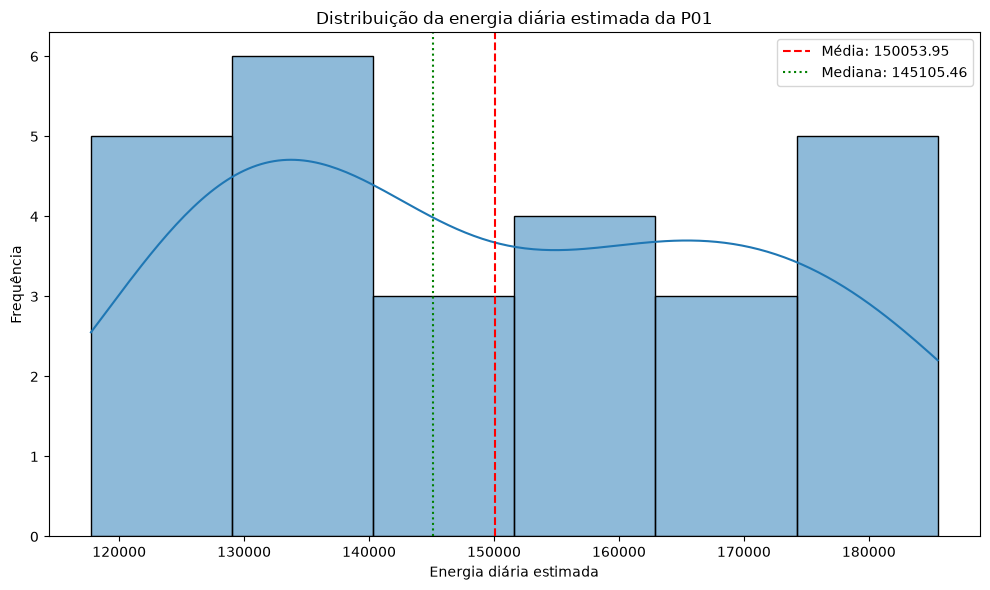

In [99]:
p01_daily_energy = complete_daily_analysis_df.loc[
    complete_daily_analysis_df["plant_code"] == "P01",
    "daily_energy_estimated"
]

visualize_distribution(
    data=p01_daily_energy,
    title="Distribuição da energia diária estimada da P01",
    x_label="Energia diária estimada"
)

A distribuição da P01 apresenta valores espalhados por uma faixa relativamente ampla. A média está ligeiramente acima da mediana, indicando uma pequena influência dos dias com maior energia estimada. Entretanto, a proximidade entre as duas medidas mostra que essa influência não é acentuada.

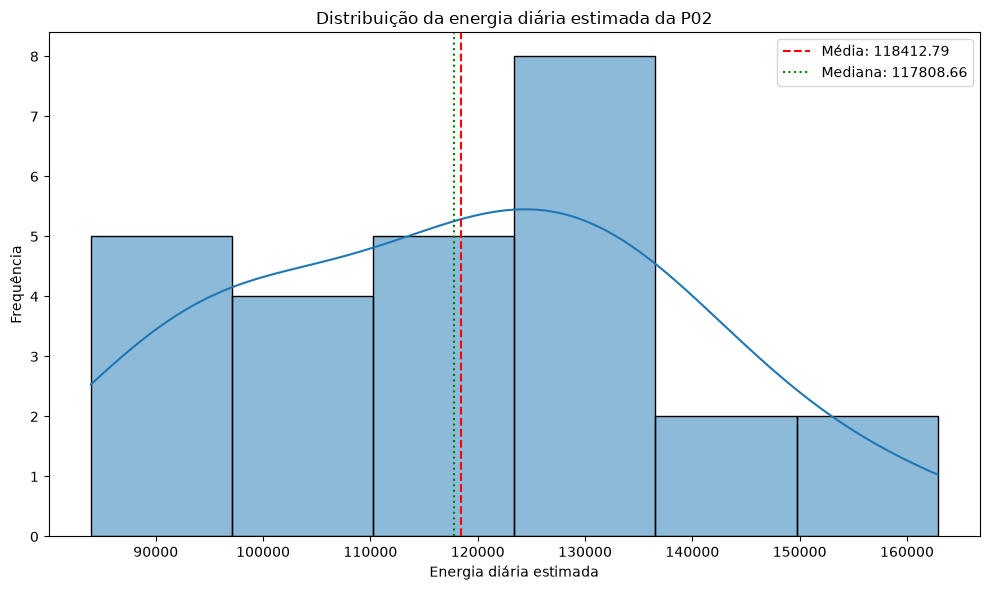

In [100]:
p02_daily_energy = complete_daily_analysis_df.loc[
    complete_daily_analysis_df["plant_code"] == "P02",
    "daily_energy_estimated"
]

visualize_distribution(
    data=p02_daily_energy,
    title="Distribuição da energia diária estimada da P02",
    x_label="Energia diária estimada"
)

Na P02, a média e a mediana aparecem quase sobrepostas, o que reforça que os valores centrais são pouco influenciados pelos extremos. A maior concentração visual ocorre na região central da distribuição, ao passo que poucos dias apresentam energia estimada nas faixas mais altas.

### 6.5 Identificação de valores atípicos

### 6.6 Medidas de dispersão

### 6.7 Assimetria e curtose


### 6.8 Comparação estatística entre as usinas

## 7. Análises direcionadas pelas perguntas

### 7.1 Qual horário do dia apresenta a maior geração média?

### 7.2 Qual usina apresentou a maior geração total estimada?

### 7.3 Quais inversores apresentaram a maior geração acumulada?

### 7.4 Em qual dia cada usina apresentou sua maior geração?

### 7.5 Quais foram as condições climáticas médias de cada usina?

### 7.6 Como a geração diária se relacionou com a temperatura e a irradiação médias?

## 8. Síntese dos resultados

## 9. Limitações da análise

## 10. Conclusão